### Cardiovascular Risk Prediction and Explainable Artificial Intelligence (XAI) Dashboard

This project demonstrates the development of an Explainable Artificial Intelligence (XAI) framework for cardiovascular risk prediction using a publicly available cardiovascular health dataset from Kaggle. The workflow covers the complete machine learning pipeline, including data preparation, feature engineering, model training, performance evaluation, and model interpretation. 

***Project Objectives:***
- Develop machine learning models for cardiovascular disease risk prediction.
- Compare model performance using multiple evaluation metrics.
- Apply explainable AI techniques to improve model transparency.
- Generate both global and patient-specific explanations of predictions.
- Build an interactive dashboard for communicating risk predictions and model explanations to different audiences.

***Dataset:***
The project uses the Cardiovascular Disease Dataset (cardio_train.csv) obtained from Kaggle. The dataset contains demographic, behavioural, and clinical characteristics commonly associated with cardiovascular disease risk, including:
- Age
- Sex
- Height and weight
- Blood pressure
- Cholesterol level
- Glucose level
- Smoking status
- Alcohol intake
- Physical activity
- Cardiovascular disease diagnosis (target variable)

***Three machine learning algorithms are developed and compared:*** 
- Logistic Regression
- Random Forest
- Gradient Boosting

***Model performance is assessed using standard classification metrics, including:***
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Confusion matrices

To improve transparency and trustworthiness, ***SHAP (SHapley Additive exPlanations)*** is used to explain model behaviour at both global and individual levels for the best performing model slected (Gradient Boosting in this case). The XAI component includes:
- Model-based feature importance analysis
- Global feature importance analysis
- SHAP summary plots
- SHAP beeswarm visualisations
- Individual patient waterfall explanations
- Patient-level risk interpretation

The final output is an ***interactive dashboard built with Dash and Plotly (app.py)***, allowing to explore cardiovascular risk predictions and corresponding explanations. The dashboard is designed to support different audiences interested in understanding the factors that influence cardiovascular risk, such as 
- Patients
- Clinicians
- ML researchers 

***Python version used:*** 3.10.9

#### 1. Clean the data
- Load the dataset
- Rename columns into readable medical labels
- Remove duplicates
- Check missing values
- Convert age from days to years if using the Kaggle dataset
- Convert height and weight into BMI

In [1]:
# Install packages

!pip install pandas numpy scikit-learn xgboost shap plotly dash joblib matplotlib

In [2]:
# Import libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [3]:
# Load the cardio dataset downloaded from Kaggle

df = pd.read_csv(r"/Users/chengchengwu/Desktop/cardio-xai-dashboard/data/cardio_train.csv", sep=";")

print(df.head())
print(df.shape)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/chengchengwu/Desktop/cardio-xai-dashboard/data/cardio_train.csv'

In [ ]:
# Rename columns into readable medical labels

df = df.rename(columns={
    "age": "Age_days",
    "gender": "Sex",
    "height": "Height_cm",
    "weight": "Weight_kg",
    "ap_hi": "Systolic_BP",
    "ap_lo": "Diastolic_BP",
    "cholesterol": "Cholesterol",
    "gluc": "Glucose",
    "smoke": "Smoking_status",
    "alco": "Alcohol_intake",
    "active": "Physical_activity",
    "cardio": "Cardiovascular_Disease"
})

print(df.columns)

Index(['id', 'Age_days', 'Sex', 'Height_cm', 'Weight_kg', 'Systolic_BP',
       'Diastolic_BP', 'Cholesterol', 'Glucose', 'Smoking_status',
       'Alcohol_intake', 'Physical_activity', 'Cardiovascular_Disease'],
      dtype='object')


In [ ]:
# Read the first five rows

df.head()

# Sex: 1 = women, 2 = men
# Cholesterol: 1 = normal, 2 = above normal, 3 = well above normal
# Glucose: 1 = normal, 2 = above normal, 3 = well above normal
# Smoking, alcohol, physical activity: 0

,id,Age_days,Sex,Height_cm,Weight_kg,Systolic_BP,Diastolic_BP,Cholesterol,Glucose,Smoking_status,Alcohol_intake,Physical_activity,Cardiovascular_Disease
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [ ]:
# Remove duplicates

print("Duplicates before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


In [ ]:
# Check missing values

missing_values = df.isnull().sum()
print(missing_values)

id                        0
Age_days                  0
Sex                       0
Height_cm                 0
Weight_kg                 0
Systolic_BP               0
Diastolic_BP              0
Cholesterol               0
Glucose                   0
Smoking_status            0
Alcohol_intake            0
Physical_activity         0
Cardiovascular_Disease    0
dtype: int64


In [ ]:
# Convert age from days to years

df["Age"] = (df["Age_days"] / 365.25).round(1)

# Drop original age column in days
df = df.drop(columns=["Age_days"])

df.head()

,id,Sex,Height_cm,Weight_kg,Systolic_BP,Diastolic_BP,Cholesterol,Glucose,Smoking_status,Alcohol_intake,Physical_activity,Cardiovascular_Disease,Age
0,0,2,168,62.0,110,80,1,1,0,0,1,0,50.4
1,1,1,156,85.0,140,90,3,1,0,0,1,1,55.4
2,2,1,165,64.0,130,70,3,1,0,0,0,1,51.6
3,3,2,169,82.0,150,100,1,1,0,0,1,1,48.2
4,4,1,156,56.0,100,60,1,1,0,0,0,0,47.8


In [ ]:
# Convert height and weight into BMI

df["Height_m"] = df["Height_cm"] / 100

df["BMI"] = df["Weight_kg"] / (df["Height_m"] ** 2)

df["BMI"] = df["BMI"].round(1)

# Optional: drop height in metres
df = df.drop(columns=["Height_m"])

df.head()

,id,Sex,Height_cm,Weight_kg,Systolic_BP,Diastolic_BP,Cholesterol,Glucose,Smoking_status,Alcohol_intake,Physical_activity,Cardiovascular_Disease,Age,BMI
0,0,2,168,62.0,110,80,1,1,0,0,1,0,50.4,22.0
1,1,1,156,85.0,140,90,3,1,0,0,1,1,55.4,34.9
2,2,1,165,64.0,130,70,3,1,0,0,0,1,51.6,23.5
3,3,2,169,82.0,150,100,1,1,0,0,1,1,48.2,28.7
4,4,1,156,56.0,100,60,1,1,0,0,0,0,47.8,23.0


#### 2. Prepare the data

In [ ]:
# Import library

from sklearn.model_selection import train_test_split

In [ ]:
# Define input features X and target variable y

features = [
    "Age",
    "Sex",
    "Systolic_BP",
    "Diastolic_BP",
    "Cholesterol",
    "Glucose",
    "Smoking_status",
    "Alcohol_intake",
    "Physical_activity",
    "BMI"
]

target = "Cardiovascular_Disease"

X = df[features]
y = df[target]

In [ ]:
# First split: training set and temporary set (70% training and 30% temporary)

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [ ]:
# Second split: validation set and test set (15% validation and 15% test)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [ ]:
# Check dataset shapes

print("Training features:", X_train.shape)
print("Validation features:", X_val.shape)
print("Test features:", X_test.shape)

print("Training labels:", y_train.shape)
print("Validation labels:", y_val.shape)
print("Test labels:", y_test.shape)

Training features: (49000, 10)
Validation features: (10500, 10)
Test features: (10500, 10)
Training labels: (49000,)
Validation labels: (10500,)
Test labels: (10500,)


In [ ]:
# Check class balance in each set

print("\nTraining class balance:")
print(y_train.value_counts(normalize=True))

print("\nValidation class balance:")
print(y_val.value_counts(normalize=True))

print("\nTest class balance:")
print(y_test.value_counts(normalize=True))


Training class balance:
0    0.500306
1    0.499694
Name: Cardiovascular_Disease, dtype: float64

Validation class balance:
0    0.500286
1    0.499714
Name: Cardiovascular_Disease, dtype: float64

Test class balance:
0    0.500286
1    0.499714
Name: Cardiovascular_Disease, dtype: float64


##### Interpretation of the output:
- The dataset was split into training (70%), validation (15%), and test (15%) subsets using stratified sampling. Class proportions were preserved across all subsets, resulting in approximately 50% cardivascular disease cases and 50% non-disease cases in each partition. This balanced distribution reduces the risk of classification bias and enables reliable evalution of predictive performance and explaninability methods.

#### 3. Train and Evalution Models

In [ ]:
# Import libraries

import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [ ]:
# Define evaluation function

def evaluate_model(model, X_test, y_test):
    """
    Evaluates a trained classification model using:
    Accuracy, Precision, Recall, F1-score, and ROC-AUC.
    """

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results = {
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1-score": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4)
    }

    return results

In [ ]:
# Import library 

from sklearn.preprocessing import StandardScaler

# Numerical columns
numerical_features = [
    "Age",
    "Systolic_BP",
    "Diastolic_BP",
    "BMI"
]

# Create copies
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

# Create scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled[numerical_features] = scaler.fit_transform(
    X_train[numerical_features]
)

# Apply same scaling to validation and test sets
X_val_scaled[numerical_features] = scaler.transform(
    X_val[numerical_features]
)

X_test_scaled[numerical_features] = scaler.transform(
    X_test[numerical_features]
)

print("Scaling complete.")

Scaling complete.


In [ ]:
# Train Logistic Regression (use scaled data for the model)


log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [ ]:
# Evaluate Logistic Regression

log_results = evaluate_model(
    log_model,
    X_test_scaled,
    y_test
)

print("Logistic Regression Results:")
print(log_results)

Logistic Regression Results:
{'Accuracy': 0.7106, 'Precision': 0.73, 'Recall': 0.6678, 'F1-score': 0.6975, 'ROC-AUC': 0.7738}


In [ ]:
# Train Random Forest (does not require scaled data)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [ ]:
# Evaluate Random Forest

rf_results = evaluate_model(
    rf_model,
    X_test,
    y_test
)

print("Random Forest Results:")
print(rf_results)

Random Forest Results:
{'Accuracy': 0.7346, 'Precision': 0.7574, 'Recall': 0.6897, 'F1-score': 0.722, 'ROC-AUC': 0.7976}


In [ ]:
# Train Gradient Boosting (does not require scaled data)

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

print("Gradient Boosting trained successfully.")

Gradient Boosting trained successfully.


In [ ]:
# Evaluate Gradient Boosting

gb_results = evaluate_model(
    gb_model,
    X_test,
    y_test
)

print("Gradient Boosting Results:")
print(gb_results)

Gradient Boosting Results:
{'Accuracy': 0.7333, 'Precision': 0.752, 'Recall': 0.6958, 'F1-score': 0.7228, 'ROC-AUC': 0.7978}


In [ ]:
# Compare all models

comparison_df = pd.DataFrame({
    "Logistic Regression": log_results,
    "Random Forest": rf_results,
    "Gradient Boosting": gb_results
}).T

comparison_df

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,0.7106,0.7300,0.6678,0.6975,0.7738
Random Forest,0.7346,0.7574,0.6897,0.7220,0.7976
Gradient Boosting,0.7333,0.7520,0.6958,0.7228,0.7978


In [ ]:
# Detailed report for Gradient Boosting (as it performs best)

gb_pred = gb_model.predict(X_test)

print("Gradient Boosting Classification Report:")
print(classification_report(y_test, gb_pred))

print("Gradient Boosting Confusion Matrix:")
print(confusion_matrix(y_test, gb_pred))

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.77      0.74      5253
           1       0.75      0.70      0.72      5247

    accuracy                           0.73     10500
   macro avg       0.73      0.73      0.73     10500
weighted avg       0.73      0.73      0.73     10500

Gradient Boosting Confusion Matrix:
[[4049 1204]
 [1596 3651]]


In [ ]:
# Save the model

import joblib

joblib.dump(
    gb_model,
    "gradient_boosting_cardio_model.pkl"
)

['gradient_boosting_cardio_model.pkl']

#### 4. Explainable AI with SHAP for the selected Gradient Boosting Model

In [ ]:
# Install package

!pip install shap

In [ ]:
# Import libraries

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)

SHAP version: 0.49.1


In [ ]:
# Select the final model

final_model = gb_model

print("Final model selected: Gradient Boosting")

Final model selected: Gradient Boosting


#### Model-based feature importance:
- This shows how the model uses the features.

In [ ]:
# Model feature importance from Gradient Boosting 

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

             Feature  Importance
2        Systolic_BP    0.733182
0                Age    0.130008
4        Cholesterol    0.075172
3       Diastolic_BP    0.026859
9                BMI    0.021684
8  Physical_activity    0.004758
5            Glucose    0.003984
6     Smoking_status    0.001612
7     Alcohol_intake    0.001486
1                Sex    0.001256


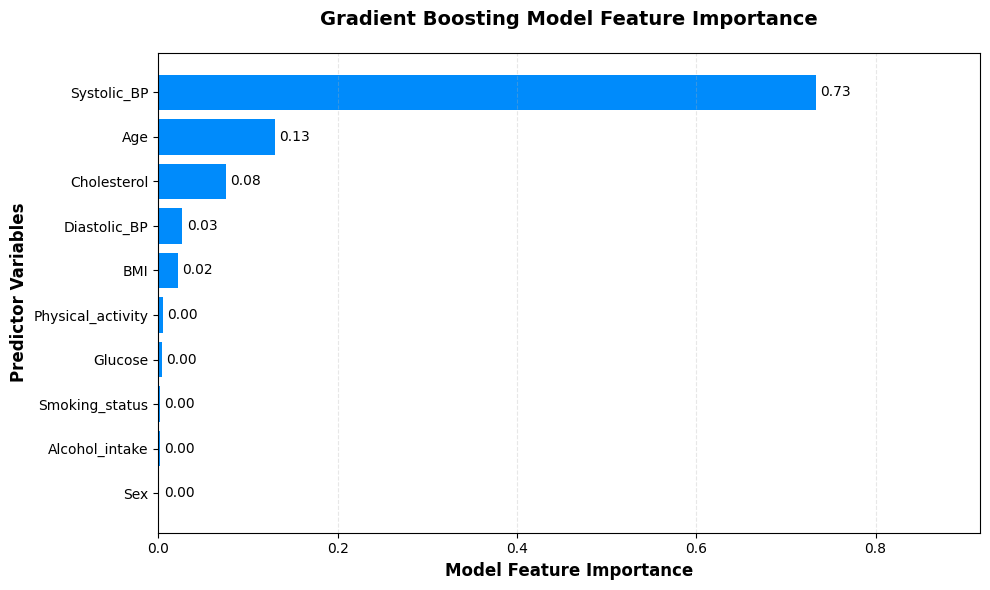

In [ ]:
# plot Gradient Boosting Model Feature Importance

plt.figure(figsize=(10, 6))

bars = plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"],
    color="#008BFB"
)

# Highest importance at top
plt.gca().invert_yaxis()

# Add value labels
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.005,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center",
        fontsize=10
    )

# Axis labels
plt.xlabel(
    "Model Feature Importance",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Predictor Variables",
    fontsize=12,
    fontweight="bold"
)

# Title
plt.title(
    "Gradient Boosting Model Feature Importance",
    fontsize=14,
    fontweight="bold",
    pad=20,
    loc="center"
)

# Light grid
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

# Extra space for labels
plt.xlim(
    0,
    feature_importance["Importance"].max() * 1.25
)

plt.tight_layout()

# Save figure
plt.savefig(
    "gradient_boosting_model_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Global Feature Importance:
- This shows which features influence predicitions most across the whole test set.

In [ ]:
# Import libraries

import shap
import matplotlib.pyplot as plt

In [ ]:
# Create a SHAP explainer

explainer = shap.Explainer(
    final_model,
    X_train
)

shap_values = explainer(
    X_test
)

print("SHAP values created successfully.")

 96%|=================== | 10104/10500 [00:25<00:00]       

SHAP values created successfully.


In [ ]:
# Check SHAP value shape

print("X_test shape:", X_test.shape)
print("SHAP values shape:", shap_values.values.shape)

X_test shape: (10500, 10)
SHAP values shape: (10500, 10)


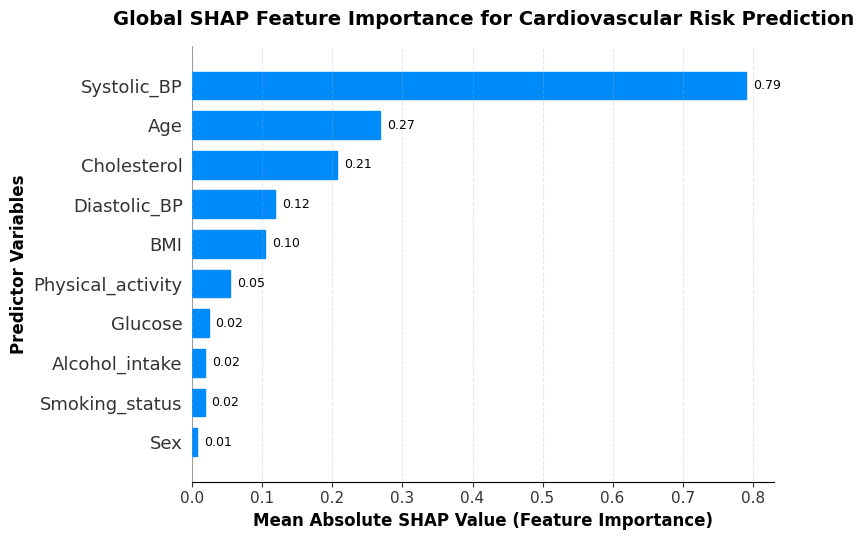

In [ ]:
# Global SHAP Feature Importance

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    max_display=10,
    show=False
)

ax = plt.gca()

# Set bars color as navy blue
for patch in ax.patches:
    patch.set_color("#008BFB")

# Add labels to bars
for patch in ax.patches:
    width = patch.get_width()

    ax.text(
        width + 0.01,
        patch.get_y() + patch.get_height()/2,
        f"{width:.2f}",
        va="center",
        fontsize=9
    )

# Axis labels
ax.set_xlabel(
    "Mean Absolute SHAP Value (Feature Importance)",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Predictor Variables",
    fontsize=12,
    fontweight="bold"
)

# Title
plt.title(
    "Global SHAP Feature Importance for Cardiovascular Risk Prediction",
    fontsize=14,
    fontweight="bold",
    pad=15,
    loc="center"
)

# Improve appearance
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

# Save high-resolution figure
plt.savefig(
    "shap_global_importance_for_cardiovascular_risk_rediction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### SHAP Summary Plot:
- This shows how features influence predictions and in which direction.

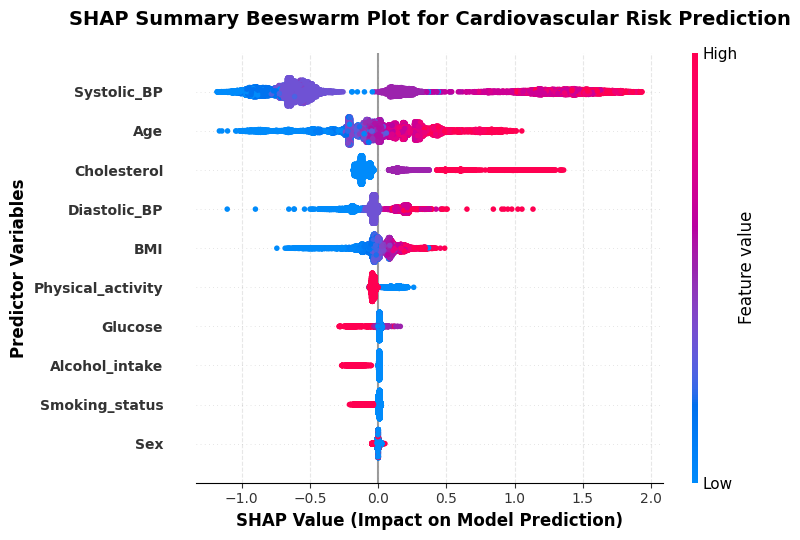

In [ ]:
# SHAP Summary Beeswarm Plot

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_test,
    max_display=10,
    show=False
)

# Get axis
ax = plt.gca()

# Title
plt.title(
    "SHAP Summary Beeswarm Plot for Cardiovascular Risk Prediction",
    fontsize=14,
    fontweight="bold",
    pad=20,
    loc="center"
)

# X-axis label
ax.set_xlabel(
    "SHAP Value (Impact on Model Prediction)",
    fontsize=12,
    fontweight="bold"
)

# Y-axis label
ax.set_ylabel(
    "Predictor Variables",
    fontsize=12,
    fontweight="bold"
)

# Improve tick labels
ax.tick_params(
    axis="both",
    labelsize=10
)

# Light grid
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

# Make feature names bold
for label in ax.get_yticklabels():
    label.set_fontweight("bold")

plt.tight_layout()

# Save high-resolution figure
plt.savefig(
    "shap_summary_beeswarm_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##### Explanation: Each point represents an individual patient. The horizontal position indicates the impact of a feature on the model prediction (SHAP value), while colour indicates the feature value, with red representing high values and blue representing low values. Features are ranked by overall importance from top to bottom.

#### Patient-level Waterfall Plot:
- This shows why a specific patient received a particular risk prediction.

In [ ]:
# Select one patient

patient_index = 50

patient_data = X_test.iloc[[patient_index]]

patient_prediction = final_model.predict(patient_data)[0]

patient_probability = final_model.predict_proba(patient_data)[0][1]

print("Patient index:", patient_index)
print("Predicted class:", patient_prediction)
print("Predicted cardiovascular disease risk:", round(patient_probability, 4))

Patient index: 50
Predicted class: 1
Predicted cardiovascular disease risk: 0.731


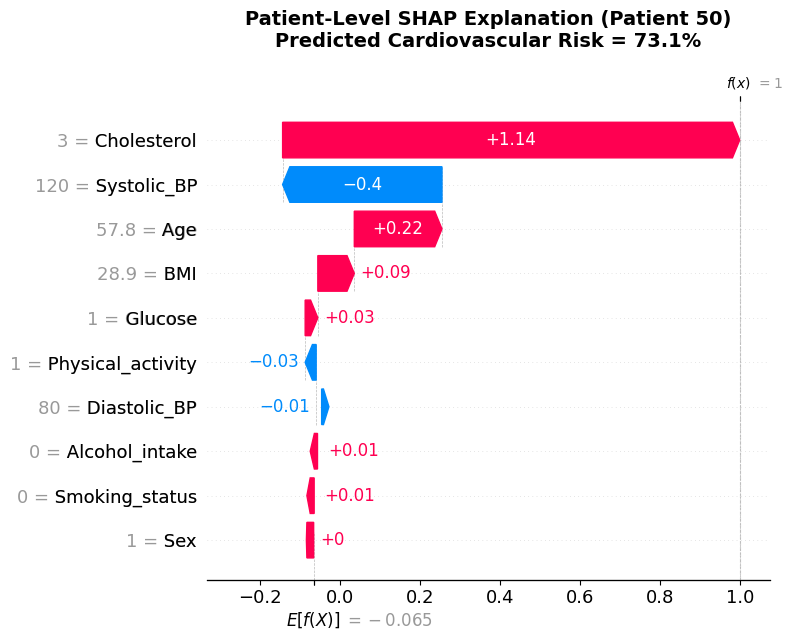

In [ ]:
# Create Patient-Level SHAP Waterfall Plot

plt.figure(figsize=(10, 6))

shap.plots.waterfall(
    shap_values[patient_index],
    max_display=10,
    show=False
)

# Get current axis
ax = plt.gca()

# Title
pred_prob = gb_model.predict_proba(
    X_test.iloc[[patient_index]]
)[0, 1]

plt.title(
    f"Patient-Level SHAP Explanation (Patient {patient_index})\nPredicted Cardiovascular Risk = {pred_prob:.1%}",
    fontsize=14,
    fontweight="bold",
    pad=20,
    loc="center"
)
# Improve tick labels
ax.tick_params(
    axis="both",
    labelsize=10
)

# Make feature labels bold
for label in ax.get_yticklabels():
    label.set_fontweight("bold")

# Add light grid
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

# Save figure
plt.savefig(
    f"shap_waterfall_patient_{patient_index}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##### Explanation: Red bars indicate factors that increase predicted cardiovascular risk, while blue bars indicate factors that decrease risk. The length of each bar represents the contribution of that feature to the individual prediction relative to the model baseline.

#### Generate Plain-language Explanations


In [ ]:
# Create patient SHAP contribution table

patient_shap_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Feature value": X_test.iloc[patient_index].values,
    "SHAP contribution": shap_values[patient_index].values
})

patient_shap_df["Absolute contribution"] = patient_shap_df[
    "SHAP contribution"
].abs()

patient_shap_df = patient_shap_df.sort_values(
    by="Absolute contribution",
    ascending=False
)

patient_shap_df

,Feature,Feature value,SHAP contribution,Absolute contribution
4,Cholesterol,3.0,1.142309,1.142309
2,Systolic_BP,120.0,-0.398249,0.398249
0,Age,57.8,0.219097,0.219097
9,BMI,28.9,0.091117,0.091117
5,Glucose,1.0,0.031661,0.031661
8,Physical_activity,1.0,-0.027517,0.027517
3,Diastolic_BP,80.0,-0.013673,0.013673
7,Alcohol_intake,0.0,0.010377,0.010377
6,Smoking_status,0.0,0.008322,0.008322
1,Sex,1.0,0.001263,0.001263


#### Explanation for Patients

In [ ]:
# Generate patient-friendly explanation

def generate_patient_explanation(patient_shap_df, patient_probability):
    top_factors = patient_shap_df.head(3)

    risk_level = (
        "Low" if patient_probability < 0.40
        else "Medium" if patient_probability < 0.70
        else "High"
    )

    explanation = f"""
Your estimated cardiovascular risk level is: {risk_level}

The model estimated your probability of cardiovascular disease as {patient_probability:.1%}.

The main factors influencing this prediction were:
"""

    for _, row in top_factors.iterrows():
        direction = "increased" if row["SHAP contribution"] > 0 else "reduced"

        explanation += (
            f"- {row['Feature']} {direction} the predicted risk.\n"
        )

    explanation += """
This result is for educational purposes only and should not be used as a medical diagnosis.
Please consult a qualified healthcare professional for medical advice.
"""

    return explanation


patient_explanation = generate_patient_explanation(
    patient_shap_df,
    patient_probability
)

print(patient_explanation)


Your estimated cardiovascular risk level is: High

The model estimated your probability of cardiovascular disease as 73.1%.

The main factors influencing this prediction were:
- Cholesterol increased the predicted risk.
- Systolic_BP reduced the predicted risk.
- Age increased the predicted risk.

This result is for educational purposes only and should not be used as a medical diagnosis.
Please consult a qualified healthcare professional for medical advice.



#### Explanation for Clinicians

In [ ]:
# Generate clinician-focused explanation

def generate_clinician_explanation(
    patient_shap_df,
    patient_probability,
    patient_prediction
):
    explanation = f"""
Clinical Explanation

Predicted class: {patient_prediction}
Predicted probability of cardiovascular disease: {patient_probability:.4f}

Top positive contributors to predicted risk:
"""

    positive_factors = patient_shap_df[
        patient_shap_df["SHAP contribution"] > 0
    ].head(5)

    for _, row in positive_factors.iterrows():
        explanation += (
            f"- {row['Feature']} = {row['Feature value']} "
            f"(SHAP: {row['SHAP contribution']:.4f})\n"
        )

    explanation += "\nTop negative contributors to predicted risk:\n"

    negative_factors = patient_shap_df[
        patient_shap_df["SHAP contribution"] < 0
    ].head(5)

    for _, row in negative_factors.iterrows():
        explanation += (
            f"- {row['Feature']} = {row['Feature value']} "
            f"(SHAP: {row['SHAP contribution']:.4f})\n"
        )

    return explanation


clinician_explanation = generate_clinician_explanation(
    patient_shap_df,
    patient_probability,
    patient_prediction
)

print(clinician_explanation)


Clinical Explanation

Predicted class: 1
Predicted probability of cardiovascular disease: 0.7310

Top positive contributors to predicted risk:
- Cholesterol = 3.0 (SHAP: 1.1423)
- Age = 57.8 (SHAP: 0.2191)
- BMI = 28.9 (SHAP: 0.0911)
- Glucose = 1.0 (SHAP: 0.0317)
- Alcohol_intake = 0.0 (SHAP: 0.0104)

Top negative contributors to predicted risk:
- Systolic_BP = 120.0 (SHAP: -0.3982)
- Physical_activity = 1.0 (SHAP: -0.0275)
- Diastolic_BP = 80.0 (SHAP: -0.0137)



#### Explanation for ML Researchers

In [ ]:
# Generate ML researcher explanation

def generate_researcher_explanation(
    patient_shap_df,
    patient_probability,
    patient_prediction
):
    base_value = shap_values.base_values[patient_index]

    explanation = f"""
ML Researcher Explanation

Model: Gradient Boosting Classifier
Prediction output: {patient_prediction}
Predicted probability: {patient_probability:.4f}
SHAP base value: {base_value:.4f}

The table below ranks features by absolute SHAP contribution.
Positive SHAP values push the prediction towards cardiovascular disease.
Negative SHAP values push the prediction away from cardiovascular disease.
"""

    return explanation


researcher_explanation = generate_researcher_explanation(
    patient_shap_df,
    patient_probability,
    patient_prediction
)

print(researcher_explanation)

patient_shap_df


ML Researcher Explanation

Model: Gradient Boosting Classifier
Prediction output: 1
Predicted probability: 0.7310
SHAP base value: -0.0650

The table below ranks features by absolute SHAP contribution.
Positive SHAP values push the prediction towards cardiovascular disease.
Negative SHAP values push the prediction away from cardiovascular disease.



,Feature,Feature value,SHAP contribution,Absolute contribution
4,Cholesterol,3.0,1.142309,1.142309
2,Systolic_BP,120.0,-0.398249,0.398249
0,Age,57.8,0.219097,0.219097
9,BMI,28.9,0.091117,0.091117
5,Glucose,1.0,0.031661,0.031661
8,Physical_activity,1.0,-0.027517,0.027517
3,Diastolic_BP,80.0,-0.013673,0.013673
7,Alcohol_intake,0.0,0.010377,0.010377
6,Smoking_status,0.0,0.008322,0.008322
1,Sex,1.0,0.001263,0.001263


#### Save SHAP Outputs for Dashboard

In [ ]:
# Save SHAP contribution table

patient_shap_df.to_csv(
    "patient_shap_explanation.csv",
    index=False
)

print("Patient SHAP explanation saved.")

Patient SHAP explanation saved.


In [ ]:
# Save global feature importance

feature_importance.to_csv(
    "global_feature_importance.csv",
    index=False
)

print("Global feature importance saved.")

Global feature importance saved.


#### 5. Build interactive explainable dashboard for cardiovascular risk prediction
- A separate app.py was built with Dash and Plotly to run the dashboard

#### 6. Run the dashboard using app.py (or app.ipynb if needed)
- To run the app, go to Terminal and find the folder containing app.py and the model file
- Then open the lcoal URL shown in the Termial (for example: http://127.0.0.1:8050)

- In case joblib and dash work in app.ipynb but not in app.py, run the following first:
    - import sys
    - print(sys.executable)
    to print the output, for example: /usr/local/bin/python3.10
- Then use the exact same path to run app.py in the Terminal
    - for example in Mac: cd ~/Desktop/cardio-xai-dashboard/notebooks/usr/local/bin/python3.10 app.py
- Install packages into that exact Python in the Terminal
    - for example in Mac: /usr/local/bin/python3.10 -m pip install joblib dash plotly pandas scikit-learn
- Test imports
    - for example in Mac: /usr/local/bin/python3.10 -c "import joblib, dash, plotly, pandas, sklearn; print('All imports working')
- Then run the app in the Terminal
    - for example in Mac: cd ~/Desktop/cardio-xai-dashboard/notebooks/usr/local/bin/python3.10 app.py
- Finally, open the url
    - for example: http://127.0.0.1:8050/